# Individual Fairness: Tutorial 3
### Fair, Transparent and Interpretable Machine Learning (2026)

---

## Introduction

In this tutorial we explore individual fairness using the **Adult dataset** (https://archive.ics.uci.edu/dataset/2/adult), which contains census information about people including age, education, marital status, occupation, and more. The task is to predict whether a person earns more than 50K per year.

We will use **gender** as the sensitive attribute throughout. According to the principle of individual fairness, the event that someone earns more than 50K per year should not depend on gender. You will investigate whether a standard classifier satisfies this principle, and compare three approaches:

1. **Naive model** — no fairness intervention
2. **Fairness through unawareness (FTU)** — omit the sensitive attribute
3. **Suppression** — omit features correlated with the sensitive attribute

Work through the notebook **before the tutorial**, completing the programming exercises marked `# <--- YOUR CODE HERE`. The analytical questions (marked **Question X**) will be discussed together in the tutorial session.

> **Note:** Do not change any code that has already been provided. Later cells depend on it.

---

## 0) Preprocessing

In [1]:
### Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score, normalized_mutual_info_score
from fairlearn.metrics import demographic_parity_ratio

In [2]:
"""
Read and clean the Adult dataset.
- Drop fnlwgt (weighting factor, not useful for classification) and education 
  (redundant with educational-num).
- Create binary target variable: 50k = 1 if income > 50K, else 0.
- Add a constant column for the intercept.
"""

df = pd.read_csv('adult_tutorial.csv')

# Print basic info
print(f'Columns: {list(df.columns)}')
print(f'Shape: {df.shape}')

# Drop redundant columns
df.drop(['fnlwgt', 'education'], axis=1, inplace=True)

# Create binary target
df['50k'] = np.where(df['income'] == '>50K', 1, 0)
objective_column = '50k'
df.drop(['income'], axis=1, inplace=True)

# Add constant
df['const'] = 1

Columns: ['age', 'workclass', 'fnlwgt', 'education', 'educational-num', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']
Shape: (9999, 15)


In [3]:
"""
Encode categorical variables as dummy variables.
Gender is our sensitive attribute. We use 'Male' as the reference category,
so the dummy variable gender_Female = 1 for female applicants, 0 for male.

For all other categorical variables, we use drop_first=True to avoid 
multicollinearity.
"""

sensitive_feature = 'gender'
reference_category = 'Male'

# Separate sensitive feature before encoding
print(f'\n{sensitive_feature} value counts:')
print(df[sensitive_feature].value_counts())

df_sensitive = df[sensitive_feature].copy()
df_sensitive_dummies = pd.get_dummies(df_sensitive, prefix=sensitive_feature,
                                       drop_first=False, dtype=float)
df_sensitive_dummies = df_sensitive_dummies.drop(
    f'{sensitive_feature}_{reference_category}', axis=1)

# Encode remaining categorical variables
df = df.drop(sensitive_feature, axis=1)
df = pd.get_dummies(df, prefix=df.select_dtypes(include=['object']).columns,
                    drop_first=True, dtype=float)

# Rejoin sensitive dummies
df = pd.concat([df, df_sensitive_dummies], axis=1)

print(f'\nNumber of columns after encoding: {df.shape[1]}')
print(f'Sensitive columns: {[c for c in df.columns if sensitive_feature in c]}')


gender value counts:
gender
Male      6674
Female    3325
Name: count, dtype: int64

Number of columns after encoding: 85
Sensitive columns: ['gender_Female']


---

## 1) Binary Classification

Train a logistic regression classifier to predict whether a person earns more 
than 50K per year. This unconstrained model serves as our baseline — we call 
it the **naive model**.

In [4]:
"""
Complete the function below to train a logistic regression classifier.
The function takes a dataframe as input and returns a fitted model.
"""

def train_binary_classifier(df, max_iter=10000):
    # Split into features and target
    X = df.drop([objective_column], axis=1)
    y = df[objective_column]

    # Define and fit the model
    model = LogisticRegression(max_iter=max_iter, solver='lbfgs', tol=1e-3)
    model.fit(X, y)

    return model


In [5]:
# Dictionaries to store predictions and probabilities across models
predictions_dict = {}
proba_dict = {}

In [6]:
"""
Split the data into training (80%) and test (20%) sets.

Think about: could it happen that some rare categories in the sensitive 
attribute appear in only one split? How would you detect and handle this?
"""

train_fraction = 0.8
train_df = df.sample(frac=train_fraction, random_state=42)
test_df  = df.drop(train_df.index)

print(f'Train size: {len(train_df)}, Test size: {len(test_df)}')

# Note: with a random split, rare categories (e.g. rare race/native-country 
# values) may appear in only one split. This causes issues because the dummy
# variable for that category will be all-zeros in one split, making it 
# uninformative. Solution: drop columns that are constant in the training set.
# (This is done in the next cell.)


Train size: 7999, Test size: 2000


In [7]:
"""
Train the naive model (no fairness constraints) and store predictions.
"""

# Drop columns with only one unique value in the training set (causes issues 
# with logistic regression)
cols_to_drop = [c for c in train_df.columns 
                if len(train_df[c].unique()) == 1 and c != 'const']
train_df = train_df.drop(cols_to_drop, axis=1)
test_df  = test_df.drop(cols_to_drop, axis=1)

# Train
naive_model = train_binary_classifier(train_df)

# Predict
X_test = test_df.drop([objective_column], axis=1)
y_pred = naive_model.predict(X_test)

# Store
predictions_dict['naive'] = y_pred
proba_dict['naive'] = naive_model.predict_proba(X_test)

---

## 2) Fairness Metrics

We use three metrics to evaluate our classifiers:

- **Accuracy**: overall classification accuracy.
- **ROC AUC**: area under the ROC curve.
- **Demographic parity ratio**: ratio of positive outcome rates across groups 
  (1.0 = perfect parity; lower values indicate disparity).
- **Symmetric uncertainty** $SU(\hat{Y}, A)$: measures residual dependence 
  between predictions $\hat{Y}$ and the sensitive attribute $A$, ranging from 
  0 (no dependence) to 1 (perfect dependence). Defined as:

$$SU(X, Y) = \frac{2 \cdot MI(X, Y)}{H(X) + H(Y)}$$

where $MI$ is mutual information and $H$ is Shannon entropy.

In [8]:
"""
Fairness metric implementations.
Note: we implement symmetric uncertainty using our own entropy function 
to match the definition from the clips exactly.
"""

def accuracy(y_true, y_pred):
    return np.sum(y_true == y_pred) / len(y_true)

def entropy(y):
    """Shannon entropy H(Y) in bits (log base 2)."""
    vals, counts = np.unique(y, return_counts=True)
    probs = counts / counts.sum()
    return -np.sum(probs * np.log2(probs + 1e-12))

def mutual_information(y1, y2):
    """
    Mutual information MI(Y1, Y2) computed from joint distribution.
    Uses log base 2 (bits), consistent with our entropy definition.
    """
    vals1, vals2 = np.unique(y1), np.unique(y2)
    mi = 0.0
    n = len(y1)
    for v1 in vals1:
        for v2 in vals2:
            p_joint = np.sum((y1 == v1) & (y2 == v2)) / n
            p1 = np.sum(y1 == v1) / n
            p2 = np.sum(y2 == v2) / n
            if p_joint > 0:
                mi += p_joint * np.log2(p_joint / (p1 * p2 + 1e-12))
    return mi

def symmetric_uncertainty(y1, y2):
    """
    Symmetric uncertainty SU(Y1, Y2) = 2*MI(Y1,Y2) / (H(Y1) + H(Y2)).
    Returns value in [0, 1].
    """
    mi = mutual_information(y1, y2)
    h1 = entropy(y1)
    h2 = entropy(y2)
    denom = h1 + h2
    return (2 * mi / denom) if denom > 0 else 0.0

def make_table(y_true, y_pred, sensitive_features, name):
    """
    Compute fairness metrics and return as a single-row DataFrame.
    """
    table = {
        'accuracy':          accuracy(y_true, y_pred),
        'roc_auc':           roc_auc_score(y_true, y_pred),
        'dem_parity_ratio':  demographic_parity_ratio(
                                 y_true, y_pred,
                                 sensitive_features=sensitive_features),
    }
    for feature in sensitive_features.columns:
        table[f'SU_{feature}'] = symmetric_uncertainty(
            y_pred.values, sensitive_features[feature].values)
    return pd.DataFrame(table, index=[name])

---

## 3) Naive Model Results

In [9]:
# Identify sensitive feature columns in the test set
sensitive_cols = [c for c in test_df.columns if sensitive_feature in c]

# Evaluate naive model
result = make_table(test_df[objective_column],
                    pd.Series(predictions_dict['naive'], index=test_df.index),
                    test_df[sensitive_cols],
                    'naive')
print(result)

       accuracy   roc_auc  dem_parity_ratio  SU_gender_Female
naive      0.85  0.764474          0.262588          0.053964


**Question 1:** Look at the symmetric uncertainty value $SU(\hat{Y}, \text{gender})$ 
for the naive model.

a) What does a value of 0 mean? What does a value of 1 mean?  
b) How would you interpret the value you obtained? Does the naive classifier 
   appear to discriminate on the basis of gender?  
c) The demographic parity ratio is a group fairness metric, while symmetric 
   uncertainty relates to individual fairness. What is the difference between 
   what these two metrics are measuring?

---

## 4) Fairness Interventions

### 4.1) Fairness Through Unawareness (FTU)

In [10]:
"""
Apply fairness through unawareness: retrain the model without the sensitive 
attribute columns.

Which columns should you remove? Think carefully — the sensitive feature has 
been encoded as dummy variable(s).
"""

# Remove sensitive columns from train and test
train_unaware = train_df.drop(sensitive_cols, axis=1)
test_unaware  = test_df.drop(sensitive_cols, axis=1)

# Train
model_unaware = train_binary_classifier(train_unaware)

# Predict (note: evaluate on original test_df for fair comparison)
X_test_unaware = test_unaware.drop([objective_column], axis=1)
y_pred = model_unaware.predict(X_test_unaware)
predictions_dict['FTU'] = y_pred
proba_dict['FTU'] = model_unaware.predict_proba(X_test_unaware)

# Evaluate
sub_result = make_table(test_df[objective_column],
                        pd.Series(y_pred, index=test_df.index),
                        test_df[sensitive_cols],
                        'FTU')
result = pd.concat([result, sub_result])
print(result)


       accuracy   roc_auc  dem_parity_ratio  SU_gender_Female
naive      0.85  0.764474          0.262588          0.053964
FTU        0.85  0.765899          0.304312          0.045960


**Question 2:** Compare the naive model and the FTU model.

a) Has accuracy changed? What does this tell you about the informativeness of 
   gender for predicting income in this dataset?  
b) Has $SU(\hat{Y}, \text{gender})$ changed? What does this tell you about 
   whether FTU is working as intended?  
c) From the clips (Clip 4), recall that FTU can fail when the sensitive 
   attribute is correlated with other features. Can you think of features in 
   this dataset that might be correlated with gender? What would this imply 
   for the FTU result you obtained?

### 4.2) Suppression

In [11]:
"""
Implement the suppression function. For each sensitive column, compute the 
correlation with all other features (excluding the target variable). 
Drop any feature whose absolute correlation with a sensitive column exceeds 
the threshold.

Note: use Pearson correlation (np.corrcoef). Be careful not to drop the 
sensitive columns themselves at this stage — they are needed to compute 
correlations with other columns.
"""

def suppress_correlated(train, test, sensitive_cols, threshold):
    num_dropped = 0
    cols_to_drop = set()

    for sens_col in sensitive_cols:
        for col in train.columns:
            # Do not drop the target, the constant, or sensitive columns themselves
            if col in [objective_column, 'const'] or col in sensitive_cols:
                continue
            corr = np.abs(np.corrcoef(train[sens_col], train[col])[0, 1])
            if corr > threshold:
                cols_to_drop.add(col)

    # Also drop the sensitive columns themselves
    cols_to_drop.update(sensitive_cols)

    train = train.drop(list(cols_to_drop), axis=1)
    test  = test.drop(list(cols_to_drop),  axis=1)
    num_dropped = len(cols_to_drop)

    return train, test, num_dropped

In [12]:
"""
Apply suppression for at least two threshold values and evaluate each model.
Try thresholds of 0.1 and 0.2 as a starting point, but feel free to explore 
others.
"""

correlation_thresholds = [0.1, 0.2]  # adjust as you like

for threshold in correlation_thresholds:
    train_sup = train_df.copy()
    test_sup  = test_df.copy()

    train_sup, test_sup, n_dropped = suppress_correlated(
        train_sup, test_sup, sensitive_cols, threshold)
    print(f'Threshold {threshold}: {n_dropped} columns dropped.')

    # Train
    model_sup = train_binary_classifier(train_sup)

    # Predict
    X_test_sup = test_sup.drop([objective_column], axis=1)
    y_pred = model_sup.predict(X_test_sup)
    predictions_dict[f'suppressed-{threshold}'] = y_pred
    proba_dict[f'suppressed-{threshold}'] = model_sup.predict_proba(X_test_sup)

    # Evaluate
    sub_result = make_table(test_df[objective_column],
                             pd.Series(y_pred, index=test_df.index),
                             test_df[sensitive_cols],
                             f'suppressed-{threshold}')
    result = pd.concat([result, sub_result])

print(result)

Threshold 0.1: 13 columns dropped.
Threshold 0.2: 7 columns dropped.
                accuracy   roc_auc  dem_parity_ratio  SU_gender_Female
naive              0.850  0.764474          0.262588          0.053964
FTU                0.850  0.765899          0.304312          0.045960
suppressed-0.1     0.814  0.668805          0.605127          0.007288
suppressed-0.2     0.842  0.740680          0.374475          0.030862


**Question 3:** Examine the suppression results across the two thresholds.

a) How many features were dropped at each threshold? Print the names of the 
   dropped features. Do they make sense as proxies for gender?  
b) How does the choice of threshold affect accuracy and $SU(\hat{Y}, \text{gender})$? 
   Is there a trade-off?  
c) This trade-off between accuracy and fairness was mentioned in Clip 2. 
   Which of the three mechanisms (pre-process, in-process, post-process) does 
   suppression correspond to?  
d) The suppression approach uses Pearson correlation as the measure of 
   dependence between features and the sensitive attribute. From Clip 4, 
   what would be a more appropriate measure, and why?

---

## 5) Visualisation

Produce at least one plot that helps communicate your results. Some ideas:

- A bar chart comparing accuracy and $SU(\hat{Y}, \text{gender})$ across models.
- Group-specific confusion matrices for the naive model.
- The distribution of predicted probabilities by gender group for the naive model.

You can use the slides and the FML book for inspiration.

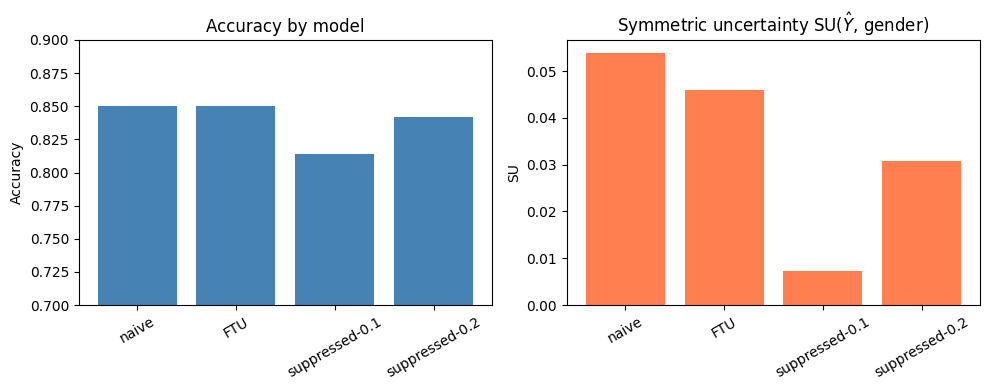

In [13]:
### Bar chart comparing accuracy and SU across models

models = list(result.index)
accuracies = result['accuracy'].values
sus = result[[c for c in result.columns if 'SU_' in c]].values.flatten()[:len(models)]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].bar(models, accuracies, color='steelblue')
axes[0].set_title('Accuracy by model')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0.7, 0.9)
axes[0].tick_params(axis='x', rotation=30)

axes[1].bar(models, sus, color='coral')
axes[1].set_title('Symmetric uncertainty SU($\hat{Y}$, gender)')
axes[1].set_ylabel('SU')
axes[1].tick_params(axis='x', rotation=30)

fig.tight_layout()
plt.show()


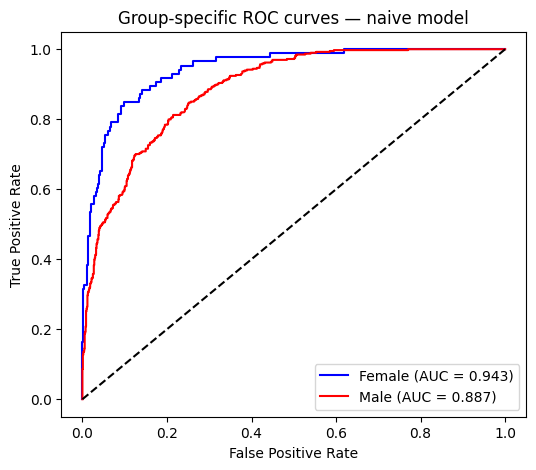

In [14]:
### Group-specific ROC curves for the naive model
from sklearn.metrics import roc_curve, auc

fig, ax = plt.subplots(figsize=(6, 5))

female_mask = test_df['gender_Female'] == 1
male_mask   = test_df['gender_Female'] == 0

naive_proba = proba_dict['naive'][:, 1]
y_true = test_df[objective_column].values

for label, mask, colour in [('Female', female_mask, 'blue'),
                            ('Male',   male_mask,   'red')]:
    fpr, tpr, _ = roc_curve(y_true[mask], naive_proba[mask])
    roc_auc = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=colour,
            label=f'{label} (AUC = {roc_auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Group-specific ROC curves — naive model')
ax.legend()
plt.show()


---

## 6) Conclusion

**Question 4:** Summarise your findings.

a) Of the three models (naive, FTU, suppression), which would you recommend 
   and why? Consider accuracy, fairness, and ease of implementation.  
b) Both FTU and suppression are **pre-processing** approaches that operate on 
   the training data. What is the fundamental limitation they share, regardless 
   of how well they reduce $SU(\hat{Y}, \text{gender})$?  
c) *(Preview of week 5)* The metrics we used today — symmetric uncertainty and 
   demographic parity ratio — measure different things. What question does each 
   one answer? Could a model score well on one but poorly on the other?

---